In [87]:
# ✅ Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input
from tensorflow.keras import layers

In [89]:
# ✅ Load Pre-split Dataset
data = np.load("Dataset/train_test_split.npz")
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# ✅ Load CNN model
cnn_model = load_model("Model/cnn2image_model.keras", compile=False)

rf_model = joblib.load("Model/rfc_model.pkl")
xgb_model = joblib.load("Model/xgb_model.pkl")
gbc_model = joblib.load("Model/gbc_model.pkl")

In [91]:
print("Training Set - X_train shape:", X_train.shape)
print("Testing Set - X_test shape:", X_test.shape)
print("Training Set - y_train shape:", y_train.shape)
print("Testing Set - y_test shape:", y_test.shape)

Training Set - X_train shape: (140030, 10)
Testing Set - X_test shape: (60013, 10)
Training Set - y_train shape: (140030,)
Testing Set - y_test shape: (60013,)


In [93]:
# ✅ CNN Predictions
# ✅ Convert Tabular to Image Format
def tabular_to_image(X, img_size=(64, 64)):
    total_pixels = img_size[0] * img_size[1]

    padded = np.zeros((X.shape[0], total_pixels))
    padded[:, :X.shape[1]] = X

    images = padded.reshape(-1, img_size[0], img_size[1], 1)
    return images

X_test_img = tabular_to_image(X_test)

In [95]:
cnn_test_preds = cnn_model.predict(X_test_img)

1876/1876 ━━━━━━━━━━━━━━━━━━━━ 141s 75ms/step


In [96]:
ml_ensemble_probs = (rf_model.predict_proba(X_test) +
                 xgb_model.predict_proba(X_test) +
                 gbc_model.predict_proba(X_test)) / 3

In [97]:
# ✅ Final prediction: average ML + CNN
ensemble_test_probs = (0.6 * ml_test_probs + 0.4 * cnn_test_preds)

In [98]:
final_pred = np.argmax(ensemble_test_probs, axis=1)


✅ Hybrid CNN + ML Ensemble Accuracy: 0.26837518537650173

Classification Report:

              precision    recall  f1-score   support

           0       0.22      0.22      0.22     12766
           1       0.34      0.34      0.34     20098
           2       0.20      0.21      0.20     11897
           3       0.26      0.26      0.26     15252

    accuracy                           0.27     60013
   macro avg       0.26      0.26      0.26     60013
weighted avg       0.27      0.27      0.27     60013



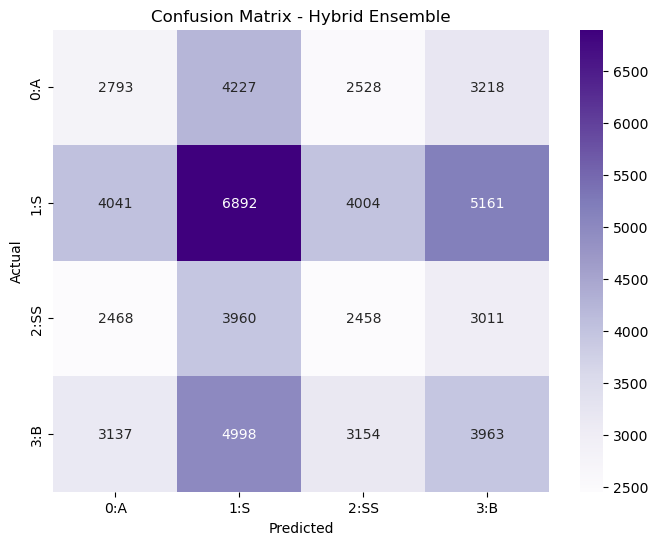

In [99]:
# ✅ Evaluate
print("\n✅ Hybrid CNN + ML Ensemble Accuracy:", accuracy_score(y_test, final_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, final_pred))

conf_matrix = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples',
            xticklabels=["0:A", "1:S", "2:SS", "3:B"],
            yticklabels=["0:A", "1:S", "2:SS", "3:B"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Hybrid Ensemble")
plt.show()

In [57]:
# ✅ False Positives Calculation
false_positives_per_class = conf_matrix.sum(axis=0) - np.diag(conf_matrix)
total_false_positives = false_positives_per_class.sum()

print("\n🚨 False Positives Per Class:")
for i, fp in enumerate(false_positives_per_class):
    label = ['A', 'S', 'SS', 'B'][i]
    print(f"  ➤ Class {i} (Label: {label}): {fp}")

print("\n❗ Total False Positives:", total_false_positives)


🚨 False Positives Per Class:
  ➤ Class 0 (Label: A): 293
  ➤ Class 1 (Label: S): 365
  ➤ Class 2 (Label: SS): 340
  ➤ Class 3 (Label: B): 0

❗ Total False Positives: 998


In [59]:
# ✅ Save final ensemble keras model wrapper
class EnsembleWrapper(tf.keras.Model):
    def __init__(self, cnn_model):
        super(EnsembleWrapper, self).__init__()
        self.cnn_model = cnn_model

    def call(self, X_img, X_tab):
        cnn_preds = self.cnn_model(X_img, training=False)
        rf_preds = tf.convert_to_tensor(rf_model.predict_proba(X_tab), dtype=tf.float32)
        xgb_preds = tf.convert_to_tensor(xgb_model.predict_proba(X_tab), dtype=tf.float32)
        gbc_preds = tf.convert_to_tensor(gbc_model.predict_proba(X_tab), dtype=tf.float32)
        ml_probs = (rf_preds + xgb_preds + gbc_preds) / 3.0
        return (cnn_preds + ml_probs) / 2.0

ensemble_model = EnsembleWrapper(cnn_model)
ensemble_model.save("Model/hybrid_ensemble_model.keras")
print("\n✅ Ensemble model saved as 'hybrid_ensemble_model.keras'")


✅ Ensemble model saved as 'hybrid_ensemble_model.keras'


D:\Anaconda_Python\Lib\site-packages\keras\src\saving\saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


✅ ML Ensemble Accuracy: 0.9853031843100661

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.96      0.97     12581
           1       0.98      0.98      0.98     20027
           2       0.97      1.00      0.98     12130
           3       1.00      1.00      1.00     15275

    accuracy                           0.99     60013
   macro avg       0.98      0.99      0.98     60013
weighted avg       0.99      0.99      0.99     60013



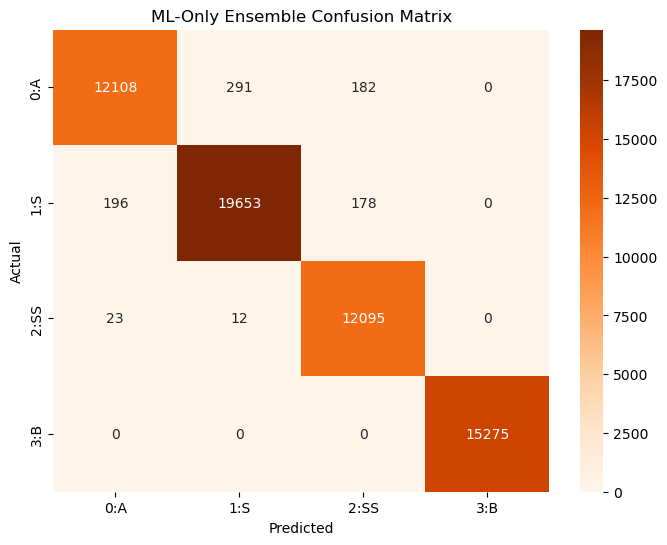


🚨 False Positives Per Class:
  ➤ Class 0 (Label: A): 219
  ➤ Class 1 (Label: S): 303
  ➤ Class 2 (Label: SS): 360
  ➤ Class 3 (Label: B): 0

❗ Total False Positives: 882


In [43]:
# 📦 Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# 📥 Load pre-split data
data = np.load("Dataset/train_test_split.npz")
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# 🔍 Load saved ML models
rf_model = joblib.load("Model/rfc_model.pkl")
xgb_model = joblib.load("Model/xgb_model.pkl")
gbc_model = joblib.load("Model/gbc_model.pkl")

# 📊 Get prediction probabilities from each model
rf_preds = rf_model.predict_proba(X_test)
xgb_preds = xgb_model.predict_proba(X_test)
gbc_preds = gbc_model.predict_proba(X_test)

# 🔗 Soft voting: average all model probabilities
ensemble_probs = (rf_preds + xgb_preds + gbc_preds) / 3
ensemble_preds = np.argmax(ensemble_probs, axis=1)

# 📈 Accuracy
accuracy = accuracy_score(y_test, ensemble_preds)
print("✅ ML Ensemble Accuracy:", accuracy)

# 📄 Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, ensemble_preds))

# 📊 Confusion Matrix
cm = confusion_matrix(y_test, ensemble_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Oranges", fmt='d',
            xticklabels=["0:A", "1:S", "2:SS", "3:B"],
            yticklabels=["0:A", "1:S", "2:SS", "3:B"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ML-Only Ensemble Confusion Matrix")
plt.show()

# 🚨 False Positives
fp_class = cm.sum(axis=0) - np.diag(cm)
total_fp = fp_class.sum()

print("\n🚨 False Positives Per Class:")
for i, fp in enumerate(fp_class):
    label = ['A', 'S', 'SS', 'B'][i]
    print(f"  ➤ Class {i} (Label: {label}): {fp}")
print("\n❗ Total False Positives:", total_fp)